In [2]:
import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import SimpleITK as sitk
from skimage.morphology import binary_opening, binary_closing, remove_small_objects, disk
from skimage.measure import label, regionprops
from skimage.segmentation import clear_border
from scipy.ndimage import binary_fill_holes, gaussian_filter1d
from skimage.filters import threshold_otsu, threshold_triangle
from scipy.signal import find_peaks


Shape: (240, 240, 1)


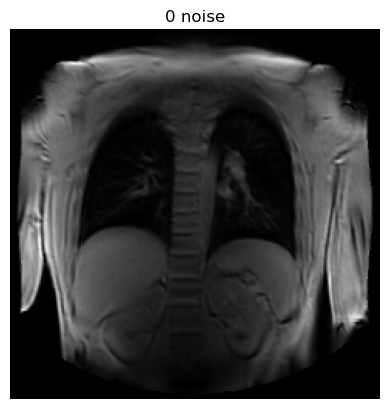

In [31]:
folder = r"C:\Users\Lenovo\Group_Project\HV_002_data\raw_IM_0025\raw_IM_0025"

files = [f for f in os.listdir(folder) if f.endswith(".nii.gz")]
files.sort()

first_file = files[0]
file_path = os.path.join(folder, first_file)

img = nib.load(file_path)
data = img.get_fdata()

print("Shape:", data.shape)

slice_index = data.shape[2] // 2
slice_img = data[:, :, slice_index]

# rotate 90 degrees
rotated = np.rot90(slice_img)

plt.imshow(rotated, cmap="gray")
plt.title("0 noise")
plt.axis("off")
plt.show()

In [4]:
print(data.shape)

(240, 240, 1)


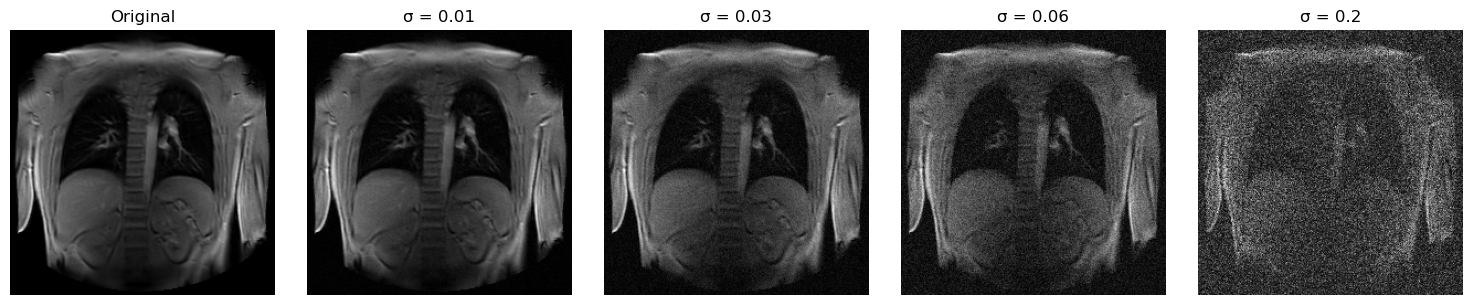

In [42]:

# --- Rician noise function ---
def add_rician_noise(image, sigma):
    n1 = np.random.normal(0, sigma, image.shape)
    n2 = np.random.normal(0, sigma, image.shape)
    noisy = np.sqrt((image + n1)**2 + n2**2)
    return noisy

# --- Extract slice from MRI ---
slice_img = data[:, :, 0]

# Normalize image (recommended for controlled noise levels)
slice_img = slice_img / np.max(slice_img)

# --- Noise levels ---
noise_levels = [0.01, 0.03, 0.06, 0.2]

# --- Generate noisy images ---
images = [slice_img]

np.random.seed(42)  # for reproducibility

for sigma in noise_levels:
    noisy = add_rician_noise(slice_img, sigma)
    images.append(noisy)

# --- Display images ---
titles = ["Original"] + [f"σ = {n}" for n in noise_levels]

plt.figure(figsize=(15,3))

for i in range(len(images)):
    plt.subplot(1,5,i+1)
    plt.imshow(np.rot90(images[i]), cmap='gray')
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [43]:
np.linspace(0,0.2,9)

array([0.   , 0.025, 0.05 , 0.075, 0.1  , 0.125, 0.15 , 0.175, 0.2  ])

In [50]:

# -------- SETTINGS --------
input_folder = r"C:\Users\Lenovo\Group_Project\HV_002_data\raw_IM_0025\raw_IM_0025"
output_folder = r"C:\Users\Lenovo\Group_Project\HV_002_data\RICE\Rice_fr\rice_sigma_0.2"

sigma = 0.2  # desired noise level

os.makedirs(output_folder, exist_ok=True)

# -------- RICIAN NOISE FUNCTION --------
def add_rician_noise(image, sigma):

    n1 = np.random.normal(0, sigma, image.shape)
    n2 = np.random.normal(0, sigma, image.shape)

    noisy = np.sqrt((image + n1)**2 + n2**2)

    return noisy


# -------- LOAD FILE LIST --------
files = [f for f in os.listdir(input_folder) if f.endswith(".nii.gz")]
files.sort()

print("Total images:", len(files))

# -------- PROCESS ALL IMAGES --------
for file in files:

    input_path = os.path.join(input_folder, file)

    # load nifti
    nii = nib.load(input_path)
    data = nii.get_fdata()

    # extract image slice
    img = data[:, :, 0]

    # normalize (important for consistent noise)
    img = img / np.max(img)

    # add Rician noise
    noisy_img = add_rician_noise(img, sigma)

    # restore 3D shape
    noisy_img = noisy_img[:, :, np.newaxis]

    # create new nifti image
    noisy_nii = nib.Nifti1Image(noisy_img, affine=nii.affine, header=nii.header)

    # save
    output_path = os.path.join(output_folder, file)
    nib.save(noisy_nii, output_path)

print("Finished generating noisy dataset.")

Total images: 256
Finished generating noisy dataset.


### BLUR

In [51]:
np.linspace(0,2,5)

array([0. , 0.5, 1. , 1.5, 2. ])

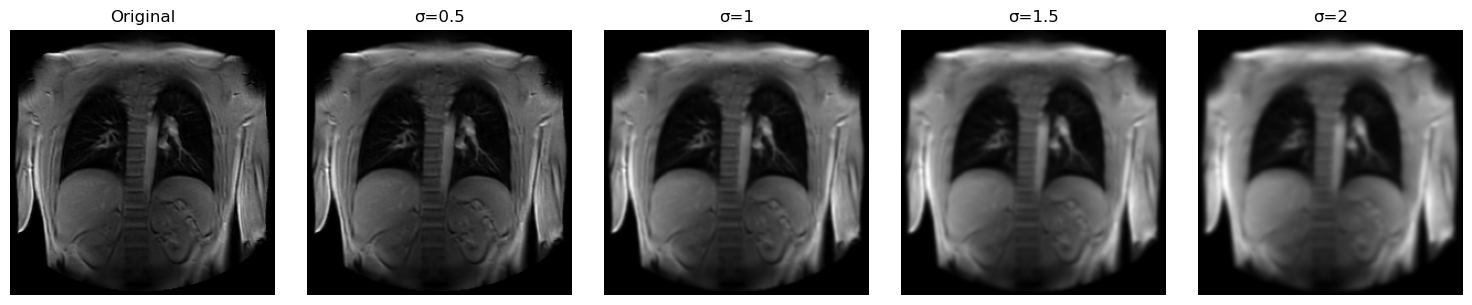

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

slice_img = data[:,:,0]
slice_img = slice_img / np.max(slice_img)

def add_blur(image, sigma):
    return gaussian_filter(image, sigma=sigma)

blur_levels = [0.5, 1, 1.5, 2]

images = [slice_img]

for s in blur_levels:
    images.append(add_blur(slice_img, s))

titles = ["Original"] + [f"σ={s}" for s in blur_levels]

plt.figure(figsize=(15,3))

for i in range(len(images)):
    
    plt.subplot(1,5,i+1)
    plt.imshow(np.rot90(images[i]), cmap='gray')
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [16]:
np.linspace(0,2,9)

array([0.  , 0.25, 0.5 , 0.75, 1.  , 1.25, 1.5 , 1.75, 2.  ])

In [17]:

# -------- SETTINGS --------
input_folder = r"C:\Users\Lenovo\Group_Project\HV_002_data\raw_IM_0025\raw_IM_0025"

blur_levels = np.array([0.25,0.5,0.75,1.0,1.25,1.5,1.75,2.0])  # blur strengths

base_output = r"C:\Users\Lenovo\Group_Project\HV_002_data\BLUR\blur_9"

# -------- LOAD FILE LIST --------
files = [f for f in os.listdir(input_folder) if f.endswith(".nii.gz")]
files.sort()

print("Total images:", len(files))

# -------- PROCESS EACH BLUR LEVEL --------
for sigma in blur_levels:

    output_folder = os.path.join(base_output, f"blur_sigma_{sigma}")
    os.makedirs(output_folder, exist_ok=True)

    print(f"\nProcessing blur sigma = {sigma}")

    for file in files:

        input_path = os.path.join(input_folder, file)

        # load nifti
        nii = nib.load(input_path)
        data = nii.get_fdata()

        # extract image slice
        img = data[:, :, 0]

        # normalize (optional but recommended)
        img = img / np.max(img)

        # apply Gaussian blur
        blurred = gaussian_filter(img, sigma=sigma)

        # restore 3D shape
        blurred = blurred[:, :, np.newaxis]

        # create nifti object
        blurred_nii = nib.Nifti1Image(blurred, affine=nii.affine, header=nii.header)

        # save
        output_path = os.path.join(output_folder, file)
        nib.save(blurred_nii, output_path)

print("\nAll blurred datasets created.")

Total images: 256

Processing blur sigma = 0.25

Processing blur sigma = 0.5

Processing blur sigma = 0.75

Processing blur sigma = 1.0

Processing blur sigma = 1.25

Processing blur sigma = 1.5

Processing blur sigma = 1.75

Processing blur sigma = 2.0

All blurred datasets created.
